# DDMRP Hybrid Algorithm — Manajemen Persediaan Adaptif
### Dataset: `dataset_after_preprocessing.xlsx` | 20 SKU | 488 Hari

---
| Bagian | Isi |
|--------|-----|
| **[SETUP]** | Install & import library |
| **[CONFIG]** | Path file & parameter — **edit bagian ini** |
| **[PART 1]** | Fungsi load data |
| **[PART 2]** | Fungsi forecast (statistik + ML + hybrid) |
| **[PART 3]** | Fungsi klasifikasi ADI-CV² |
| **[PART 4]** | Fungsi DDMRP simulator + GA + Monte Carlo |
| **[PART 5]** | Fungsi ROP + pipeline + evaluasi |
| **[RUN 1]** | Load & eksplorasi data |
| **[RUN 2]** | Forecast satu SKU |
| **[RUN 3]** | Klasifikasi + GA optimizer satu SKU |
| **[RUN 4]** | Pipeline lengkap satu SKU (DDMRP vs ROP) |
| **[RUN 5]** | Sensitivity analysis |
| **[RUN 6]** | Export Excel |



## [SETUP] — Install & Import

In [1]:
!pip install openpyxl -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, sys, math, json, pickle
from copy import deepcopy
from typing import Dict, List, Tuple, Optional
from scipy.optimize import minimize
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor,
                               HistGradientBoostingRegressor, ExtraTreesRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print("✅ Library berhasil diimport")

✅ Library berhasil diimport


In [3]:
drive.mount('/content/drive', force_remount=True)
print("✅ Drive mounted")

Mounted at /content/drive
✅ Drive mounted


## [CONFIG] — Konfigurasi Global ← Edit di sini

In [4]:
# ─── SESUAIKAN PATH INI ────────────────────────────────────────
FILE_PATH  = '/content/dataset after preprocessing.xlsx'
OUTPUT_DIR = '/content'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── PARAMETER ─────────────────────────────────────────────────
TRAIN_RATIO    = 0.80   # 80% train, 20% test
SL_TARGET      = 0.95   # target service level minimum
GA_POP_SIZE    = 30     # ukuran populasi GA
GA_N_GEN       = 80     # jumlah generasi GA
MC_N_SCENARIOS = 50     # jumlah skenario Monte Carlo

# ADI-CV² thresholds (Syntetos & Boylan 2005)
ADI_THRESHOLD  = 1.32
CV2_THRESHOLD  = 0.49

# MOQ method: 'eoq' | 'dlt' | 'week' | 'none'
#MOQ_METHOD = 'eoq'

print("✅ Config loaded")
print(f"   File   : {FILE_PATH}")
print(f"   Output : {OUTPUT_DIR}")
#print(f"   MOQ    : {MOQ_METHOD}")

✅ Config loaded
   File   : /content/dataset after preprocessing.xlsx
   Output : /content


## [PART 1] — Data Loading

**Kolom sales:** `ID Item`, `Date`, `Demand `, `Sales Price Price After Discont`, `Promo Discount`
**Kolom master:** `Material Number`, `Lead Time_Days`, `Sales Price`, `Purchase Price`, `Holding Cost Rate/day`, `Lost Sale Rate/Each`, `Logistic Cost/Order`

**Catatan asumsi:**
- `IsPromo` dibuat dari `Promo Discount > 0`
- `PromoType` = `"NONE"` (tidak ada di data)  
- `Holding Cost Rate/day` sudah dalam format per hari (÷ 365 sudah dilakukan di sumber)
- `Pack Size` = 1 (tidak ada di data)
- `Std Dev LT` = 10% × DLT


In [5]:
def load_all_data(file_path=FILE_PATH):
    """Load sales dan master data dari Excel."""
    print(f"Loading: {file_path}")
    df_s = pd.read_excel(file_path, sheet_name='sales')
    df_m = pd.read_excel(file_path, sheet_name='sku_master')

    # Bersihkan tipe data
    df_s['Date']     = pd.to_datetime(df_s['Date'])
    df_s['Demand ']  = pd.to_numeric(df_s['Demand '],  errors='coerce').fillna(0)
    df_s['Promo Discount'] = pd.to_numeric(df_s['Promo Discount'], errors='coerce').fillna(0)

    # Buat kolom turunan — TIDAK ADA di data asli
    df_s['IsPromo']         = df_s['Promo Discount'] > 0
    df_s['PromoType']       = 'NONE'          # tidak ada di dataset baru
    df_s['PromoDiscountPct']= df_s['Promo Discount']

    n_sku = df_s['ID Item'].nunique()
    print(f"✅ Sales    : {len(df_s):,} baris | {n_sku} SKU | "
          f"{df_s['Date'].min().date()} s/d {df_s['Date'].max().date()}")
    print(f"✅ Master   : {len(df_m)} SKU")
    return {'sales': df_s, 'master': df_m}


def get_sku_list(data, show=True):
    """Tampilkan daftar semua SKU."""
    df_s = data['sales']; df_m = data['master']
    grp = df_s.groupby('ID Item').agg(
        Grup        =('Nama Item','first'),
        Tgl_Mulai   =('Date','min'),
        Tgl_Akhir   =('Date','max'),
        Jml_Hari    =('Date','count'),
        Total_Demand=('Demand ','sum'),
        ADU         =('Demand ','mean'),
    ).reset_index()
    grp = grp.merge(df_m[['Material Number','Lead Time_Days','Logistic Cost/Order']],
                    left_on='ID Item', right_on='Material Number', how='left')
    grp = grp.drop(columns=['Material Number'])
    grp['ADU'] = grp['ADU'].round(1)
    grp['Tgl_Mulai'] = grp['Tgl_Mulai'].dt.date
    grp['Tgl_Akhir'] = grp['Tgl_Akhir'].dt.date
    if show:
        print("\n=== DAFTAR SKU ===")
        print(grp.to_string(index=False))
    return grp


def get_sku_demand(data, sku, start_date=None, end_date=None):
    """Ambil time series demand harian satu SKU."""
    df = data['sales']
    d  = df[df['ID Item'] == sku].copy()
    if d.empty:
        raise ValueError(f"SKU {sku} tidak ditemukan.")
    if start_date: d = d[d['Date'] >= pd.to_datetime(start_date)]
    if end_date:   d = d[d['Date'] <= pd.to_datetime(end_date)]

    d = d[['Date','Demand ','Sales Price Price After Discont',
            'IsPromo','PromoDiscountPct','PromoType']].copy()
    d.columns = ['Date','Demand','Price','IsPromo','PromoDiscountPct','PromoType']
    d = d.sort_values('Date').reset_index(drop=True)

    # Isi tanggal yang hilang
    dr = pd.date_range(d['Date'].min(), d['Date'].max(), freq='D')
    d  = pd.DataFrame({'Date':dr}).merge(d, on='Date', how='left')
    d['Demand']          = d['Demand'].fillna(0)
    d['IsPromo']         = d['IsPromo'].fillna(False)
    d['PromoDiscountPct']= d['PromoDiscountPct'].fillna(0.0)
    d['PromoType']       = d['PromoType'].fillna('NONE')
    d['Price']           = d['Price'].ffill()

    print(f"✅ SKU {sku} | {d['Date'].min().date()} s/d {d['Date'].max().date()} | "
          f"{len(d)} hari | demand total: {d['Demand'].sum():,.0f}")
    return d.reset_index(drop=True)


def get_sku_params(data, sku):
    """Ambil parameter biaya & operasional satu SKU dari master."""
    df_m = data['master']
    row  = df_m[df_m['Material Number'] == sku]
    if row.empty:
        raise ValueError(f"SKU {sku} tidak ditemukan di master.")
    row = row.iloc[0]

    dlt   = int(row['Lead Time_Days'])
    price = float(row['Sales Price'])
    buy   = float(row['Purchase Price'])

    # Holding Cost Rate/day — sudah dalam format per hari
    hold_day = float(row['Holding Cost Rate/day']) * price

    return {
        'sku'                  : int(sku),
        'group'                : str(row['Material Group']),
        'dlt'                  : dlt,
        'lt_std'               : round(dlt * 0.10, 2),   # asumsi 10% x DLT
        'pack_size'            : int(row['MOQ']),          # asumsi
        'price_ea'             : round(price, 2),
        'purchase_price'       : round(buy, 2),
        'margin_pct'           : round((price - buy) / price * 100, 1),
        'hold_rate_annual'     : round(float(row['Holding Cost Rate/day']) * 365, 4),
        'hold_cost_per_unit_day': round(hold_day, 6),
        'lost_sale_rate'       : float(row['Lost Sale Rate/Each']),
        'penalty_per_unit'     : round(float(row['Lost Sale Rate/Each']) * price, 2),
        'order_cost'           : float(row['Logistic Cost/Order']),
        'moq'                  : int(row['MOQ']),
    }


print("✅ Part 1 — fungsi data loading siap")

✅ Part 1 — fungsi data loading siap


## [PART 2] — Demand Forecasting

In [6]:
# ── Metrik evaluasi ──────────────────────────────────────────
def compute_metrics(actual, predicted, naive_err=None):
    actual    = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    err       = actual - predicted
    abs_err   = np.abs(err)
    mae  = np.mean(abs_err)
    rmse = np.sqrt(np.mean(err**2))
    bias = np.mean(err)
    nz   = actual > 0
    mape = np.mean(abs_err[nz] / actual[nz]) * 100 if nz.sum() > 0 else np.nan
    mase = mae / naive_err if naive_err and naive_err > 0 else np.nan
    w20  = (abs_err[nz] / actual[nz] <= 0.20).mean()*100 if nz.sum() > 0 else np.nan
    w10  = (abs_err[nz] / actual[nz] <= 0.10).mean()*100 if nz.sum() > 0 else np.nan
    return {'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'MAPE*': round(mape,2) if not np.isnan(mape) else None,
            'MASE': round(mase,4) if not np.isnan(mase) else None,
            'Bias': round(bias,2),
            'Within10pct': round(w10,1) if not np.isnan(w10) else None,
            'Within20pct': round(w20,1) if not np.isnan(w20) else None,
            'N_zero': int((actual==0).sum())}

def naive_mae(train):
    return float(np.mean(np.abs(np.diff(train)))) if len(train)>1 else 1.0

# ── Model statistik ──────────────────────────────────────────
def forecast_ma(train, n, window=7):
    h = list(train)
    p = []
    for _ in range(n):
        p.append(np.mean(h[-min(window,len(h)):]))
        h.append(p[-1])
    return np.array(p)

def forecast_ses(train, n):
    def mse(a):
        s=train[0]; e=0
        for v in train[1:]: e+=(v-s)**2; s=a[0]*v+(1-a[0])*s
        return e
    res   = minimize(mse,[0.3],bounds=[(0.01,0.99)],method='L-BFGS-B')
    alpha = float(res.x[0])
    s = train[0]
    for v in train[1:]: s=alpha*v+(1-alpha)*s
    return np.full(n, max(s,0)), alpha

def forecast_holt(train, n):
    def sse(p):
        a,b=p; lv=train[0]; tr=train[1]-train[0] if len(train)>1 else 0; e=0
        for v in train[1:]:
            e+=(v-lv-tr)**2; nl=a*v+(1-a)*(lv+tr); tr=b*(nl-lv)+(1-b)*tr; lv=nl
        return e
    res = minimize(sse,[0.3,0.1],bounds=[(0.01,0.99)]*2,method='L-BFGS-B')
    a,b = res.x
    lv=train[0]; tr=train[1]-train[0] if len(train)>1 else 0
    for v in train[1:]:
        nl=a*v+(1-a)*(lv+tr); tr=b*(nl-lv)+(1-b)*tr; lv=nl
    return np.maximum([lv+(h+1)*tr for h in range(n)],0), a, b

def forecast_holtwinters(train, n, season=7):
    if len(train)<2*season:
        p,_,_=forecast_holt(train,n); return p
    def hw(p):
        a,b,g=p; lv=np.mean(train[:season])
        tr=(np.mean(train[season:2*season])-np.mean(train[:season]))/season
        se=[train[i]-lv for i in range(season)]; e=0
        for t in range(len(train)):
            si=t%season; e+=(train[t]-lv-tr-se[si])**2
            nl=a*(train[t]-se[si])+(1-a)*(lv+tr)
            tr=b*(nl-lv)+(1-b)*tr; se[si]=g*(train[t]-nl)+(1-g)*se[si]; lv=nl
        return e
    res=minimize(hw,[0.3,0.1,0.1],bounds=[(0.01,0.99)]*3,method='L-BFGS-B')
    a,b,g=res.x
    lv=np.mean(train[:season])
    tr=(np.mean(train[season:2*season])-np.mean(train[:season]))/season
    se=[train[i]-lv for i in range(season)]
    for t in range(len(train)):
        si=t%season; nl=a*(train[t]-se[si])+(1-a)*(lv+tr)
        tr=b*(nl-lv)+(1-b)*tr; se[si]=g*(train[t]-nl)+(1-g)*se[si]; lv=nl
    return np.maximum([lv+(h+1)*tr+se[(len(train)+h)%season] for h in range(n)],0)

def forecast_croston(train, n, alpha=0.1):
    nz=np.where(train>0)[0]
    if len(nz)<2: return np.full(n,np.mean(train))
    z=float(train[nz[0]]); p=float(nz[0]+1); q=0
    for t in range(1,len(train)):
        q+=1
        if train[t]>0: z=alpha*train[t]+(1-alpha)*z; p=alpha*q+(1-alpha)*p; q=0
    return np.full(n,max(z/p,0))

print("✅ Model statistik siap")

✅ Model statistik siap


In [81]:
# ── Outlier handling ────────────────────────────────────────
def clean_demand_adaptive(series, dates, adu=None, low_pct=0.02, verbose=True):
    """Bersihkan anomali demand dengan threshold adaptif per SKU."""
    series = np.array(series, dtype=float)
    if adu is None:
        adu = np.mean(series[series>0])

    low_thr  = adu * low_pct
    nz       = series[series>0]
    Q1,Q3    = np.percentile(nz,25), np.percentile(nz,75)
    high_thr = Q3 + 2.0*(Q3-Q1)

    mask = (series<low_thr) | (series>high_thr)
    cleaned = series.copy()
    for i in np.where(mask)[0]:
        lo=max(0,i-7); hi=min(len(series),i+8)
        nbrs = series[lo:hi]
        valid = nbrs[(nbrs>=low_thr)&(nbrs<=high_thr)]
        cleaned[i] = np.median(valid) if len(valid)>=3 else np.median(nz[(nz>=low_thr)&(nz<=high_thr)])

    rows=[]
    for i in np.where(mask)[0]:
        rows.append({'Hari':i+1,
                     'Tanggal': dates.iloc[i].date() if i<len(dates) else None,
                     'Nilai Asli':series[i], 'Nilai Baru':cleaned[i],
                     'Tipe':'LOW' if series[i]<low_thr else 'HIGH'})
    rpt = pd.DataFrame(rows)
    if verbose and not rpt.empty:
        print(f"  Threshold: LOW<{low_thr:.1f} | HIGH>{high_thr:.1f}")
        print(f"  Anomali  : {len(rpt)} hari")
        print(rpt.to_string(index=False))
    return cleaned, rpt

# ── Feature engineering (dengan promo) ──────────────────────
def make_features(all_series, all_dates, all_promo_pct, all_ispromo):
    """Buat feature matrix untuk model ML — tanpa PromoType."""
    df = pd.DataFrame({'y':all_series, 'date':pd.to_datetime(all_dates)})
    y_s = df['y'].shift(1)

    for lag in [1,2,3,7,14,21,28]:
        df[f'lag_{lag}'] = df['y'].shift(lag)
    for w in [7,14,28]:
        df[f'rm_{w}']  = y_s.rolling(w,min_periods=3).mean()
        df[f'rs_{w}']  = y_s.rolling(w,min_periods=3).std()
    df['ewm7']  = y_s.ewm(span=7, min_periods=3).mean()
    df['ewm14'] = y_s.ewm(span=14,min_periods=3).mean()

    df['dow']        = df['date'].dt.dayofweek
    df['month']      = df['date'].dt.month
    df['day']        = df['date'].dt.day
    df['is_weekend'] = (df['dow']>=5).astype(int)
    df['is_payday']  = df['day'].isin([25,26,27,28,1,2,3]).astype(int)
    df['is_mon']     = (df['dow']==0).astype(int)
    df['is_fri']     = (df['dow']==4).astype(int)

    # Promo features dari Promo Discount % (tidak perlu PromoType)
    promo_arr = np.array(all_ispromo, dtype=int)
    disc_arr  = np.array(all_promo_pct, dtype=float)
    df['is_promo']       = promo_arr
    df['promo_discount'] = disc_arr
    df['promo_lag1']     = pd.Series(promo_arr).shift(1).fillna(0).values
    df['promo_lag7']     = pd.Series(promo_arr).shift(7).fillna(0).values
    df['disc_lag1']      = pd.Series(disc_arr).shift(1).fillna(0).values

    # Post-promo effect
    post1 = np.zeros(len(promo_arr),dtype=int)
    for i in range(1,len(promo_arr)):
        if promo_arr[i]==0 and promo_arr[i-1]==1: post1[i]=1
    df['post_promo1'] = post1

    return df.drop(columns=['date'])


def split_xy(all_series, tr_d, te_d, promo_df, n_train):
    """Split fitur menjadi train/test."""
    all_dates = pd.concat([tr_d, te_d], ignore_index=True)
    all_promo = pd.concat([promo_df.iloc[:n_train],
                            promo_df.iloc[n_train:]], ignore_index=True)

    df = make_features(all_series, all_dates,
                       all_promo['PromoDiscountPct'].values,
                       all_promo['IsPromo'].astype(int).values)
    df['y'] = all_series
    fcols = [c for c in df.columns if c!='y']

    df_tr = df.iloc[:n_train].dropna()
    df_te = df.iloc[n_train:].copy()
    X_tr  = df_tr[fcols]; y_tr = df_tr['y']
    X_te  = df_te[fcols].copy()
    for col in X_te.columns:
        if X_te[col].isna().any():
            X_te[col] = X_te[col].fillna(X_tr[col].mean())
    return X_tr, y_tr, X_te

print("✅ Feature engineering siap")

✅ Feature engineering siap


In [82]:
# ── Model ML ────────────────────────────────────────────────
def run_elasticnet(tr, te, tr_d, te_d, promo_df):
    all_s = np.concatenate([tr,te])
    X_tr,y_tr,X_te = split_xy(all_s, tr_d, te_d, promo_df, len(tr))
    sx = MinMaxScaler()
    m  = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=2000)
    m.fit(sx.fit_transform(X_tr), y_tr)
    return np.maximum(m.predict(sx.transform(X_te)), 0)

def run_hgb(tr, te, tr_d, te_d, promo_df):
    all_s = np.concatenate([tr,te])
    X_tr,y_tr,X_te = split_xy(all_s, tr_d, te_d, promo_df, len(tr))
    m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                       max_depth=5, random_state=42)
    m.fit(X_tr, y_tr)
    return np.maximum(m.predict(X_te), 0)

def run_rf(tr, te, tr_d, te_d, promo_df):
    all_s = np.concatenate([tr,te])
    X_tr,y_tr,X_te = split_xy(all_s, tr_d, te_d, promo_df, len(tr))
    m = RandomForestRegressor(n_estimators=200, max_depth=8,
                               min_samples_leaf=4, n_jobs=-1, random_state=42)
    m.fit(X_tr, y_tr)
    return np.maximum(m.predict(X_te), 0)

def run_mlp(tr, te, tr_d, te_d, promo_df):
    all_s = np.concatenate([tr,te])
    X_tr,y_tr,X_te = split_xy(all_s, tr_d, te_d, promo_df, len(tr))
    sx = MinMaxScaler(); sy = MinMaxScaler()
    m  = MLPRegressor(hidden_layer_sizes=(128,64), activation='relu',
                      learning_rate_init=0.001, max_iter=500,
                      early_stopping=True, random_state=42)
    m.fit(sx.fit_transform(X_tr), sy.fit_transform(y_tr.values.reshape(-1,1)).ravel())
    return np.maximum(sy.inverse_transform(
        m.predict(sx.transform(X_te)).reshape(-1,1)).ravel(), 0)

# ── DOW Segmented ElasticNet ─────────────────────────────────
def run_dow_en(tr, te, tr_d, te_d, promo_df):
    """ElasticNet terpisah untuk Weekday (Mon-Fri) dan Weekend (Sat-Sun)."""
    all_s = np.concatenate([tr,te])
    all_d = pd.concat([tr_d,te_d], ignore_index=True)
    all_p = pd.concat([promo_df.iloc[:len(tr)],
                        promo_df.iloc[len(tr):len(tr)+len(te)]], ignore_index=True)
    df_feat = make_features(all_s, all_d, all_p['PromoDiscountPct'].values,
                             all_p['IsPromo'].astype(int).values)
    df_feat['y'] = all_s
    fcols  = [c for c in df_feat.columns if c!='y']
    df_tr  = df_feat.iloc[:len(tr)].dropna()
    df_te  = df_feat.iloc[len(tr):].copy()
    dow_tr = pd.to_datetime(tr_d).dt.dayofweek.values
    dow_te = pd.to_datetime(te_d).dt.dayofweek.values
    preds  = np.zeros(len(te))
    for seg, dows in [('WD',[0,1,2,3,4]),('WE',[5,6])]:
        mtr = np.isin(dow_tr[:len(df_tr)], dows)
        mte = np.isin(dow_te, dows)
        Xs  = df_tr[fcols].iloc[mtr]; ys = df_tr['y'].iloc[mtr]
        Xp  = df_te[fcols].iloc[mte].copy()
        if len(Xs)<5 or len(Xp)==0:
            preds[mte] = np.mean(tr); continue
        for col in Xp.columns:
            if Xp[col].isna().any(): Xp[col]=Xp[col].fillna(Xs[col].mean())
        sx = MinMaxScaler()
        m  = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=2000)
        m.fit(sx.fit_transform(Xs), ys)
        preds[mte] = np.maximum(m.predict(sx.transform(Xp)), 0)
    return preds

# ── Ensemble GA ──────────────────────────────────────────────
def run_ensemble_ga(preds_dict, actual):
    """Bobot optimal dari GA sederhana — minimasi MAE pada test."""
    names  = list(preds_dict.keys())
    matrix = np.column_stack([preds_dict[m] for m in names])
    n = len(names)
    pop = [np.random.dirichlet(np.ones(n)) for _ in range(30)]
    best_w = pop[0]
    best_f = -np.mean(np.abs(actual - matrix@best_w))
    for _ in range(20):
        scores = [(-np.mean(np.abs(actual - matrix@w)), w) for w in pop]
        scores.sort(key=lambda x:-x[0])
        parents = [s[1] for s in scores[:15]]
        if scores[0][0] > best_f:
            best_f = scores[0][0]; best_w = scores[0][1].copy()
        new_pop = parents[:]
        while len(new_pop)<30:
            p1=parents[np.random.randint(15)]; p2=parents[np.random.randint(15)]
            child = np.maximum(0.5*p1+0.5*p2 + np.random.normal(0,0.05,n), 0)
            if child.sum()>0: child/=child.sum()
            new_pop.append(child)
        pop = new_pop
    best_w = np.maximum(best_w,0); best_w/=best_w.sum()
    return np.maximum(matrix@best_w, 0), {m:round(float(w),4) for m,w in zip(names,best_w)}


# ── Main forecast runner ─────────────────────────────────────
def run_forecast(df_demand, sku, verbose=True):
    """Jalankan semua model dan bandingkan. Return dict hasil."""
    series_raw = df_demand['Demand'].values.astype(float)
    dates      = df_demand['Date'].reset_index(drop=True)
    promo_df   = df_demand[['IsPromo','PromoDiscountPct','PromoType']].reset_index(drop=True)

    adu_raw = float(np.mean(series_raw[series_raw>0]))   # sementara untuk cleaning
    clean, rpt = clean_demand_adaptive(series_raw, dates, adu=adu_raw, verbose=verbose)
    adu = float(np.mean(clean[clean>0]))   # ADU final dari data clean


    n     = len(clean)
    split = max(int(n*TRAIN_RATIO), 60)
    tr    = clean[:split]; te_clean = clean[split:]
    te_raw= clean[split:]   # evaluasi pakai nilai clean
    tr_d  = dates.iloc[:split].reset_index(drop=True)
    te_d  = dates.iloc[split:].reset_index(drop=True)
    p_tr  = promo_df.iloc[:split].reset_index(drop=True)
    p_te  = promo_df.iloc[split:split+len(te_clean)].reset_index(drop=True)
    p_all = pd.concat([p_tr,p_te], ignore_index=True)
    nm    = naive_mae(tr)
    n_te  = len(te_raw)

    if verbose:
        print(f"\nTrain: {split} hari | Test: {n_te} hari | ADU: {np.mean(tr):.1f}")

    results={}; preds={}
    def _add(tag, fn, info):
        try:
            p = fn()
            if p is not None:
                preds[tag]=p; results[tag]=compute_metrics(te_raw,p,nm)
                results[tag]['Info']=info
                if verbose: print(f"  ✅ {tag:<28} MAE={results[tag]['MAE']:.1f}")
        except Exception as e:
            if verbose: print(f"  ❌ {tag:<28} {str(e)[:50]}")

    _add('M01-MA',        lambda: forecast_ma(tr,n_te),                    'window=7')
    _add('M03-SES',       lambda: forecast_ses(tr,n_te)[0],                'auto-alpha')
    _add('M04-Holt',      lambda: forecast_holt(tr,n_te)[0],               'trend')
    _add('M05-HoltWinters',lambda: forecast_holtwinters(tr,n_te),          'season=7')
    _add('M06-Croston',   lambda: forecast_croston(tr,n_te),               'intermittent')
    _add('M11-EN+Promo',  lambda: run_elasticnet(tr,te_clean,tr_d,te_d,p_all), 'ElasticNet+Promo')
    _add('M18-HGB+Promo', lambda: run_hgb(tr,te_clean,tr_d,te_d,p_all),   'HGB+Promo')
    _add('M07-RF+Promo',  lambda: run_rf(tr,te_clean,tr_d,te_d,p_all),    'RF+Promo')
    _add('M10-MLP+Promo', lambda: run_mlp(tr,te_clean,tr_d,te_d,p_all),   'MLP+Promo')
    _add('M25-DOW-EN',    lambda: run_dow_en(tr,te_clean,tr_d,te_d,p_all),'DOW-Segmented EN')
    if len(preds)>=4:
        _add('M26-Ensemble-GA', lambda: run_ensemble_ga(preds,te_raw)[0],  'GA-weighted ensemble')

    df_cmp = pd.DataFrame([{'Model':m,**v} for m,v in results.items()])
    df_cmp = df_cmp.sort_values('MAE').reset_index(drop=True)
    df_cmp.insert(0,'Rank',range(1,len(df_cmp)+1))
    best = df_cmp.iloc[0]['Model']
    if verbose:
        print(f"\n{'='*55}")
        cols=['Rank','Model','MAE','Within10pct','Within20pct','MASE','Bias']
        cols=[c for c in cols if c in df_cmp.columns]
        print(df_cmp[cols].to_string(index=False))
        print(f"\n🏆 Terbaik: {best} | MAE={results[best]['MAE']} | "
              f"Error%={results[best]['MAE']/np.mean(tr)*100:.1f}%")

    return {'sku':sku,'comparison':df_cmp,'best_model':best,
            'best_metrics':results[best],'predictions':preds,
            'actual_test':te_raw,'test_dates':te_d,
            'train_size':split,'series_clean':clean,'outlier_report':rpt,
            'adu':round(float(np.mean(clean[:split][clean[:split]>0])), 2)}

print("✅ Part 2 — fungsi forecast siap")

✅ Part 2 — fungsi forecast siap


## [PART 3] — Klasifikasi ADI-CV²

In [83]:
VF_SPACE  = {'SMOOTH':(0.10,0.30),'ERRATIC':(0.25,0.55),
             'INTERMITTENT':(0.30,0.65),'LUMPY':(0.55,1.00)}
LTF_SPACE = {'SHORT':(0.61,1.00),'MEDIUM':(0.41,0.60),'LONG':(0.20,0.40)}

def classify_sku(df_demand, params, verbose=True):
    """Hitung ADI, CV², kategori, dan search space VF/LTF untuk GA."""
    s  = df_demand['Demand'].values.astype(float)
    nz = s[s>0]; n = len(s); k = len(nz)
    adu = float(np.mean(s))

    if k==0: return {}
    adi = n/k
    mean_nz = np.mean(nz)
    cv2 = float((np.std(nz,ddof=1)/mean_nz)**2) if k>1 and mean_nz>0 else 0.0
    cv2_all = float((np.std(s,ddof=1)/adu)**2) if adu>0 else 0.0

    if   adi<=ADI_THRESHOLD and cv2<=CV2_THRESHOLD: cat = 'SMOOTH'
    elif adi<=ADI_THRESHOLD and cv2>CV2_THRESHOLD:  cat = 'ERRATIC'
    elif adi>ADI_THRESHOLD  and cv2<=CV2_THRESHOLD: cat = 'INTERMITTENT'
    else:                                            cat = 'LUMPY'

    dlt = params['dlt']
    lt_cat = 'SHORT' if dlt<=10 else ('MEDIUM' if dlt<=25 else 'LONG')
    vf_lo,vf_hi   = VF_SPACE.get(cat,(0.10,1.00))
    ltf_lo,ltf_hi = LTF_SPACE.get(lt_cat,(0.41,0.60))
    vf_init  = (vf_lo+vf_hi)/2
    ltf_init = (ltf_lo+ltf_hi)/2

    bzr = adu*dlt*ltf_init
    tor = bzr*vf_init
    toy = tor + adu*dlt
    tog = toy + bzr

    result = {
        'sku':params['sku'],'group':params['group'],'dlt':dlt,'lt_category':lt_cat,
        'adu':round(adu,2),'n_days':n,'n_zero':int((s==0).sum()),
        'adi':round(adi,4),'cv2':round(cv2,4),'cv2_all':round(cv2_all,4),'category':cat,
        'vf_low':vf_lo,'vf_high':vf_hi,'ltf_low':ltf_lo,'ltf_high':ltf_hi,
        'vf_init':round(vf_init,4),'ltf_init':round(ltf_init,4),
        'bzr':round(bzr,1),'tor':round(tor,1),'toy':round(toy,1),'tog':round(tog,1),
    }

    if verbose:
        emoji = {'SMOOTH':'🟢','ERRATIC':'🟡','INTERMITTENT':'🟠','LUMPY':'🔴'}
        print(f"\n{'='*55}")
        print(f"  KLASIFIKASI SKU {params['sku']} | {params['group']}")
        print(f"{'='*55}")
        print(f"  ADI   = {adi:.4f}  (threshold {ADI_THRESHOLD})")
        print(f"  CV²   = {cv2:.4f}  (threshold {CV2_THRESHOLD})")
        print(f"  Kategori: {emoji.get(cat,'⚪')} {cat}")
        print(f"  DLT   = {dlt} hari ({lt_cat})")
        print(f"  Search space: VF=[{vf_lo:.2f},{vf_hi:.2f}] | LTF=[{ltf_lo:.2f},{ltf_hi:.2f}]")
        print(f"  Buffer awal : TOR={tor:.0f} | TOY={toy:.0f} | TOG={tog:.0f}")
    return result

print("✅ Part 3 — fungsi klasifikasi siap")

✅ Part 3 — fungsi klasifikasi siap


## [PART 4] — DDMRP Simulator + GA + Monte Carlo

In [84]:
def round_up_pack(qty, pack):
    if qty<=0: return 0
    return int(math.ceil(qty/max(int(pack),1)))*max(int(pack),1)

def simulate_ddmrp(demands, forecast, dates, vf, ltf, dlt, pack_size,
                    unit_price, hold_cost_per_unit_day, order_cost,
                    penalty_mult, lt_std=0.0, verbose=False):
    """
    Simulator DDMRP — tanpa look-ahead.
    QD = demand aktual hari ini + forecast H+1..H+DLT yang > OST
    """
    n   = len(demands)
    adu = float(np.mean(demands))
    ost = adu  # OST = ADU

    bzr = adu*dlt*ltf
    tor = bzr*vf
    toy = tor + adu*dlt
    tog = toy + max(bzr, pack_size)

    oh = toy  # initial OH = TOY (realistis)
    pipeline = {}
    rows = []

    for t in range(n):
        date = pd.Timestamp(dates.iloc[t]).normalize()
        receipt = float(pipeline.pop(date, 0.0))
        oh += receipt

        # On-order
        op = sum(float(q) for d,q in pipeline.items()
                 if 1 <= (pd.Timestamp(d).normalize()-date).days <= dlt)

        # QD — pakai forecast untuk H+1..H+DLT (tidak look-ahead)
        qd = float(demands[t])
        for k in range(1, dlt+1):
            j = t+k
            if j < len(forecast) and forecast[j] > ost:
                qd += forecast[j]

        nfe  = oh + op - qd
        zone = 'RED' if nfe<=tor else ('YELLOW' if nfe<=toy else 'GREEN')

        q = 0
        if nfe <= toy:
            q = int(max((tog-nfe, pack_size)))

        if q > 0:
            lt_actual = max(1,int(round(np.random.normal(dlt,lt_std)))) if lt_std>0 else dlt
            arr = (date+pd.Timedelta(days=lt_actual)).normalize()
            pipeline[arr] = pipeline.get(arr,0.0) + float(q)

        dem = float(demands[t])
        shipped = min(dem, oh); unmet = max(dem-shipped, 0.0)
        oh -= shipped

        rows.append({'date':date.date(),'demand':round(dem,2),
                     'forecast':round(float(forecast[t]) if t<len(forecast) else 0,2),
                     'receipt':round(receipt,2),'OH_end':round(oh,2),
                     'OP':round(op,2),'QD':round(qd,2),'NFE':round(nfe,2),
                     'zone':zone,'order_qty':int(q),
                     'shipped':round(shipped,2),'unmet':round(unmet,2),
                     'holding_cost':round(oh*hold_cost_per_unit_day,2),
                     'order_cost':round(order_cost if q>0 else 0,2),
                     'penalty_cost':round(unmet*penalty_mult,2),
                     'total_cost':round(oh*hold_cost_per_unit_day +
                                         (order_cost if q>0 else 0) +
                                         unmet*penalty_mult, 2)})

    df = pd.DataFrame(rows)
    td = float(df['demand'].sum()); ts = float(df['shipped'].sum())
    ns = int((df['unmet']>1e-6).sum())
    kpi = {'vf':round(vf,4),'ltf':round(ltf,4),
           'bzr':round(bzr,1),'tor':round(tor,1),'toy':round(toy,1),'tog':round(tog,1),
           'fill_rate':round(ts/td,4) if td>0 else 1.0,
           'csl':round(1-ns/n,4), 'n_stockout':ns,
           'total_cost':round(float(df['total_cost'].sum()),0),
           'hold_cost':round(float(df['holding_cost'].sum()),0),
           'order_cost':round(float(df['order_cost'].sum()),0),
           'penalty_cost':round(float(df['penalty_cost'].sum()),0),
           'n_orders':int((df['order_qty']>0).sum()),
           'avg_oh':round(float(df['OH_end'].mean()),1),
           'df_detail':df}
    if verbose:
        print(f"  VF={vf:.3f} LTF={ltf:.3f} | FR={kpi['fill_rate']*100:.2f}% | "
              f"Cost=Rp{kpi['total_cost']/1e6:.1f}jt | Stockout={ns}hr")
    return kpi


class GeneticOptimizer:
    """GA untuk optimasi [VF, LTF]."""
    def __init__(self, vf_bounds, ltf_bounds, sl_target=0.95,
                 pop_size=30, n_gen=40, verbose=True):
        self.vf_b=vf_bounds; self.ltf_b=ltf_bounds
        self.sl=sl_target; self.ps=pop_size; self.ng=n_gen; self.verbose=verbose
        self.best=None; self.best_fit=-np.inf; self.history=[]

    def _rand(self):
        return np.array([np.random.uniform(*self.vf_b),
                         np.random.uniform(*self.ltf_b)])

    def _fit(self, ind, sim_fn):
        kpi = sim_fn(vf=ind[0], ltf=ind[1])
        cost = kpi['total_cost']
        sl   = kpi['fill_rate']
        pen  = cost*(self.sl-sl)*100*0.5 if sl<self.sl else 0
        return -(cost+pen)

    def run(self, sim_fn, vf_init, ltf_init):
        pop = ([np.array([np.clip(np.random.normal(vf_init,0.05),*self.vf_b),
                          np.clip(np.random.normal(ltf_init,0.05),*self.ltf_b)])
                for _ in range(self.ps//3)] +
               [self._rand() for _ in range(self.ps - self.ps//3)])
        for gen in range(self.ng):
            scores = [self._fit(ind,sim_fn) for ind in pop]
            bi = int(np.argmax(scores))
            if scores[bi]>self.best_fit:
                self.best_fit=scores[bi]; self.best=pop[bi].copy()
            self.history.append({'generation':gen+1,'best_fitness':self.best_fit,
                                  'avg_fitness':float(np.mean(scores)),
                                  'best_vf':self.best[0],'best_ltf':self.best[1]})
            if self.verbose and (gen%10==0 or gen==self.ng-1):
                kpi=sim_fn(vf=self.best[0],ltf=self.best[1])
                print(f"    Gen {gen+1:3d} | VF={self.best[0]:.3f} LTF={self.best[1]:.3f} | "
                      f"FR={kpi['fill_rate']*100:.1f}% Cost=Rp{kpi['total_cost']/1e6:.1f}jt")
            idx = np.argsort(scores)[::-1]
            parents = [pop[i].copy() for i in idx[:self.ps//2]]
            new_pop = parents[:max(2,int(self.ps*0.2))]
            sigma = 0.05*(1-gen/self.ng)+0.01
            while len(new_pop)<self.ps:
                p1=parents[np.random.randint(len(parents))]
                p2=parents[np.random.randint(len(parents))]
                c = np.where(np.random.rand(2)<0.5, p1, p2)
                if np.random.rand()<0.3:
                    c[0]=np.clip(c[0]+np.random.normal(0,sigma),*self.vf_b)
                if np.random.rand()<0.3:
                    c[1]=np.clip(c[1]+np.random.normal(0,sigma),*self.ltf_b)
                new_pop.append(c)
            pop=new_pop[:self.ps]

        return {'vf_opt':round(float(self.best[0]),4),
                'ltf_opt':round(float(self.best[1]),4),
                'kpi':sim_fn(vf=self.best[0],ltf=self.best[1]),
                'history':pd.DataFrame(self.history)}


def run_monte_carlo(demands, forecast, dates, vf_opt, ltf_opt,
                    params, moq, n_scenarios=50):
    """Uji robustness parameter GA dengan 50 skenario acak."""
    cv = float(np.std(demands[demands>0])/np.mean(demands[demands>0]))
    rows=[]
    for s in range(n_scenarios):
        noise = np.clip(np.random.normal(1.0,cv*0.3,len(demands)),0.5,2.0)
        dem   = np.maximum(demands*noise,0)
        kpi   = simulate_ddmrp(dem,forecast,dates,vf_opt,ltf_opt,
                                params['dlt'],moq,params['price_ea'],
                                params['hold_cost_per_unit_day'],
                                params['order_cost'],params['penalty_per_unit'],
                                params['lt_std'])
        rows.append({'scenario':s+1,'fill_rate':kpi['fill_rate'],
                     'csl':kpi['csl'],'total_cost':kpi['total_cost'],
                     'n_stockout':kpi['n_stockout'],'avg_oh':kpi['avg_oh']})
    df=pd.DataFrame(rows)
    s={}
    for col in ['fill_rate','csl','total_cost','avg_oh']:
        s[col]={'mean':df[col].mean(),'p5':df[col].quantile(0.05),
                'p50':df[col].median(),'p95':df[col].quantile(0.95)}
    sl_met=(df['fill_rate']>=0.95).mean()*100
    print(f"  MC ({n_scenarios} skenario): FR={s['fill_rate']['mean']*100:.2f}% | "
          f"SL≥95%={sl_met:.1f}% | Cost P50=Rp{s['total_cost']['p50']/1e6:.1f}jt")
    return {'df_mc':df,'summary':s,'sl_met_pct':sl_met}

print("✅ Part 4 — simulator, GA, Monte Carlo siap")

✅ Part 4 — simulator, GA, Monte Carlo siap


## [PART 5] — ROP Konvensional

In [85]:
def simulate_rop(demands, dates, dlt, pack_size, unit_price,
                 hold_cost_per_unit_day, order_cost, penalty_mult,
                 service_factor=1.645, lt_std=0.0):
    """
    Reorder Point konvensional.
    Order dipicu saat OH + OnOrder <= ROP.
    Jumlah order = EOQ.
    """
    n   = len(demands)
    adu = np.mean(demands); std = np.std(demands,ddof=1)
    ss  = service_factor*std*np.sqrt(dlt)
    rop = adu*dlt + ss

    # EOQ
    eoq = pack_size

    oh=rop+eoq; pipeline={}; rows=[]
    for t in range(n):
        date = pd.Timestamp(dates.iloc[t]).normalize()
        receipt = float(pipeline.pop(date,0.0))
        oh += receipt
        op = sum(float(q) for d,q in pipeline.items()
                 if 1<=(pd.Timestamp(d).normalize()-date).days<=dlt)
        q=0
        if oh+op<=rop:
            q=eoq
            lt_a=max(1,int(round(np.random.normal(dlt,lt_std)))) if lt_std>0 else dlt
            arr=(date+pd.Timedelta(days=lt_a)).normalize()
            pipeline[arr]=pipeline.get(arr,0.0)+float(q)
        dem=float(demands[t]); shipped=min(dem,oh); unmet=max(dem-shipped,0.0); oh-=shipped
        rows.append({'date':date.date(),'demand':round(dem,2),
                     'OH_end':round(oh,2),'OP':round(op,2),
                     'shipped':round(shipped,2),'unmet':round(unmet,2),'order_qty':int(q),
                     'holding_cost':round(oh*hold_cost_per_unit_day,2),
                     'order_cost':round(order_cost if q>0 else 0,2),
                     'penalty_cost':round(unmet*penalty_mult,2),
                     'total_cost':round(oh*hold_cost_per_unit_day+
                                         (order_cost if q>0 else 0)+unmet*penalty_mult,2)})
    df=pd.DataFrame(rows)
    td=float(df['demand'].sum()); ts=float(df['shipped'].sum())
    ns=int((df['unmet']>1e-6).sum())
    return {'method':'ROP','rop':round(rop,1),'ss':round(ss,1),'eoq':eoq,
            'fill_rate':round(ts/td,4) if td>0 else 1.0,
            'csl':round(1-ns/n,4),'n_stockout':ns,
            'total_cost':round(float(df['total_cost'].sum()),0),
            'hold_cost':round(float(df['holding_cost'].sum()),0),
            'order_cost':round(float(df['order_cost'].sum()),0),
            'penalty_cost':round(float(df['penalty_cost'].sum()),0),
            'n_orders':int((df['order_qty']>0).sum()),
            'avg_oh':round(float(df['OH_end'].mean()),1),
            'df_detail':df}

print("✅ Part 5 — ROP siap")

✅ Part 5 — ROP siap


## [RUN 1] — Load & Eksplorasi Data

In [86]:
# Load data
data = load_all_data(FILE_PATH)
all_skus = sorted(data['sales']['ID Item'].unique().tolist())
print(f"\nTotal SKU: {len(all_skus)}")

# Daftar SKU
sku_list = get_sku_list(data)

Loading: /content/dataset after preprocessing.xlsx
✅ Sales    : 9,760 baris | 20 SKU | 2024-05-01 s/d 2025-08-31
✅ Master   : 20 SKU

Total SKU: 20

=== DAFTAR SKU ===
 ID Item         Grup  Tgl_Mulai  Tgl_Akhir  Jml_Hari  Total_Demand   ADU  Lead Time_Days  Logistic Cost/Order
 1000001     FOOD-DRY 2024-05-01 2025-08-31       488        301099 617.0               7               150000
 1000002      BEV-RTD 2024-05-01 2025-08-31       488        221665 454.2               7               150000
 1000003    BEV-WATER 2024-05-01 2025-08-31       488        371597 761.5               7               150000
 1000004  HHP-LAUNDRY 2024-05-01 2025-08-31       488         71100 145.7               7               150000
 1000005 FOOD-COOKING 2024-05-01 2025-08-31       488        130360 267.1               7               150000
 1000006 PERS-BA-DIAP 2024-05-01 2025-08-31       488         47427  97.2               7               150000
 1000007    PERS-CARE 2024-05-01 2025-08-31       488  

In [87]:
# Ringkasan parameter satu SKU
SKU = 1000001   # ← ganti sesuai kebutuhan
params = get_sku_params(data, SKU)
print(f"\n{'='*55}")
print(f"  PARAMETER SKU {SKU} | {params['group']}")
print(f"{'='*55}")
for k, v in params.items():
    print(f"  {k:<30}: {v}")


  PARAMETER SKU 1000001 | FOOD-DRY
  sku                           : 1000001
  group                         : FOOD-DRY
  dlt                           : 7
  lt_std                        : 0.7
  pack_size                     : 4000
  price_ea                      : 4628.25
  purchase_price                : 3239.78
  margin_pct                    : 30.0
  hold_rate_annual              : 0.18
  hold_cost_per_unit_day        : 2.282427
  lost_sale_rate                : 0.3
  penalty_per_unit              : 1388.48
  order_cost                    : 150000.0
  moq                           : 4000


✅ SKU 1000001 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 301,099


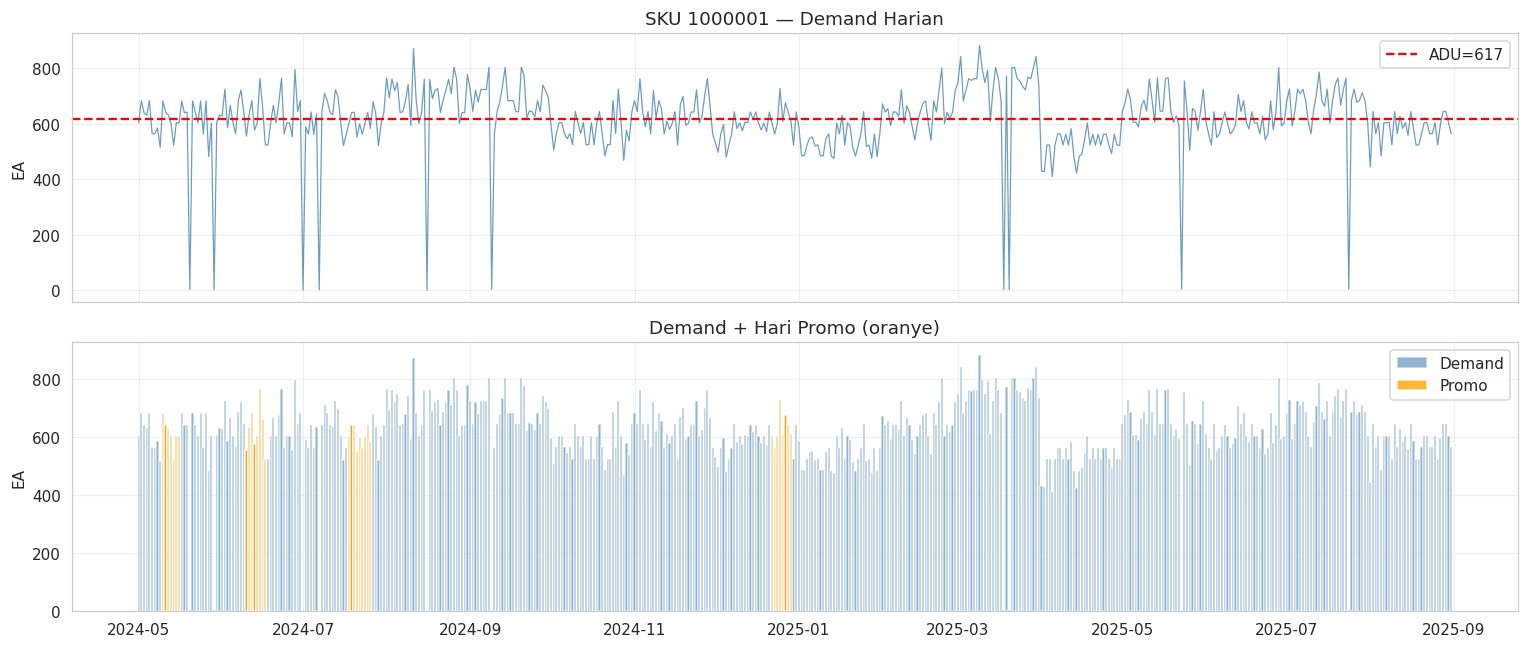

Hari promo: 32 | Avg diskon: 10.7%


In [88]:
# Visualisasi demand satu SKU
df = get_sku_demand(data, SKU)
s  = df['Demand'].values
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df['Date'], s, lw=0.8, color='steelblue', alpha=0.8)
ax1.axhline(np.mean(s), color='red', ls='--', lw=1.5, label=f'ADU={np.mean(s):.0f}')
ax1.set_title(f'SKU {SKU} — Demand Harian'); ax1.set_ylabel('EA'); ax1.legend()
ax1.grid(alpha=0.3)

# Promo overlay
promo = df[df['IsPromo']]
ax2.bar(df['Date'], df['Demand'], width=0.8, color='steelblue', alpha=0.6, label='Demand')
ax2.bar(promo['Date'], promo['Demand'], width=0.8, color='orange', alpha=0.8, label='Promo')
ax2.set_title('Demand + Hari Promo (oranye)'); ax2.set_ylabel('EA'); ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_demand_sku{SKU}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Hari promo: {df['IsPromo'].sum()} | Avg diskon: {df[df['IsPromo']]['PromoDiscountPct'].mean()*100:.1f}%")

## [RUN 2] — Forecast Demo

In [89]:
# ── Pilih SKU ──
SKU = 1000001   # ← ganti sesuai kebutuhan

df_fc = get_sku_demand(data, SKU)
result_fc = run_forecast(df_fc, SKU, verbose=True)

✅ SKU 1000001 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 301,099
  Threshold: LOW<12.3 | HIGH>922.0
  Anomali  : 10 hari
 Hari    Tanggal  Nilai Asli  Nilai Baru Tipe
   20 2024-05-20         3.0       622.5  LOW
   29 2024-05-29         3.0       618.5  LOW
   62 2024-07-01         2.0       604.0  LOW
   68 2024-07-07         2.0       643.0  LOW
  108 2024-08-16         1.0       706.0  LOW
  132 2024-09-09         4.0       703.0  LOW
  322 2025-03-18         3.0       763.0  LOW
  324 2025-03-20         3.0       763.0  LOW
  388 2025-05-23         5.0       645.0  LOW
  450 2025-07-24         5.0       685.0  LOW

Train: 390 hari | Test: 98 hari | ADU: 631.8
  ✅ M01-MA                       MAE=62.2
  ✅ M03-SES                      MAE=66.1
  ✅ M04-Holt                     MAE=104.6
  ✅ M05-HoltWinters              MAE=62.3
  ✅ M06-Croston                  MAE=63.1
  ✅ M11-EN+Promo                 MAE=45.2
  ✅ M18-HGB+Promo                MAE=51.0
  ✅ M07-RF+Promo    

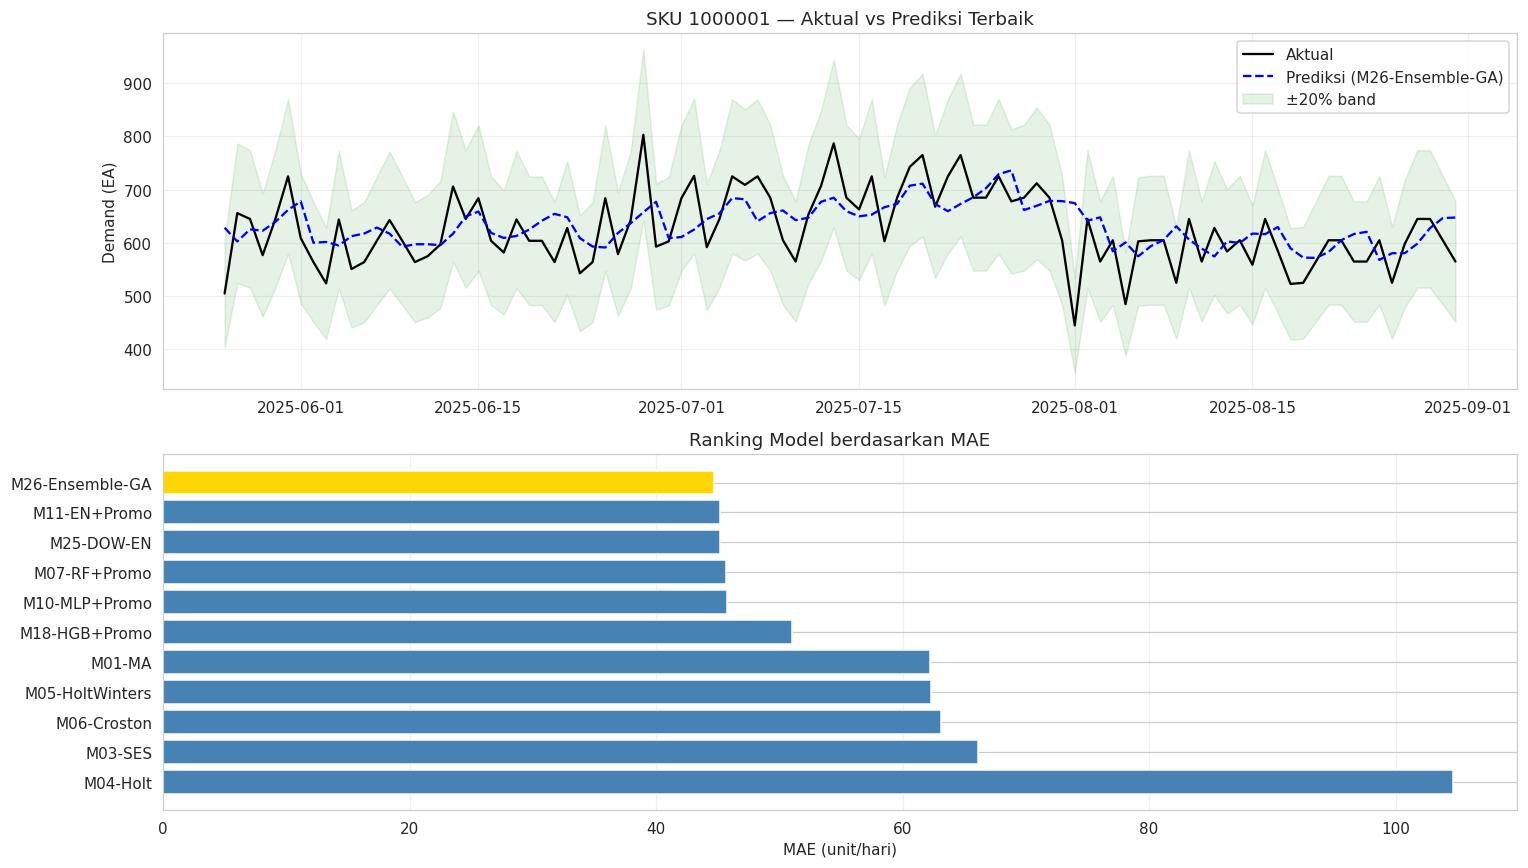


🏆 Model terbaik: M26-Ensemble-GA
   MAE      : 44.68 unit/hari
   Error%   : 7.1%
   Within20%: 95.9% hari


In [90]:
# Visualisasi hasil forecast
best  = result_fc['best_model']
preds = result_fc['predictions'][best]
td    = result_fc['test_dates']
act   = result_fc['actual_test']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Aktual vs Prediksi
axes[0].plot(td, act,   'k-',  lw=1.5, label='Aktual')
axes[0].plot(td, preds, 'b--', lw=1.5, label=f'Prediksi ({best})')
axes[0].fill_between(td, act*0.8, act*1.2, alpha=0.1, color='green', label='±20% band')
axes[0].set_title(f'SKU {SKU} — Aktual vs Prediksi Terbaik')
axes[0].set_ylabel('Demand (EA)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Ranking model
df_cmp = result_fc['comparison']
colors = ['gold' if i==0 else 'steelblue' for i in range(len(df_cmp))]
axes[1].barh(df_cmp['Model'][::-1], df_cmp['MAE'][::-1], color=colors[::-1])
axes[1].set_title('Ranking Model berdasarkan MAE'); axes[1].set_xlabel('MAE (unit/hari)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_forecast_sku{SKU}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Model terbaik: {best}")
print(f"   MAE      : {result_fc['best_metrics']['MAE']} unit/hari")
print(f"   Error%   : {result_fc['best_metrics']['MAE']/result_fc['adu']*100:.1f}%")
print(f"   Within20%: {result_fc['best_metrics'].get('Within20pct')}% hari")

## [RUN 3] — Klasifikasi + GA Optimizer

In [91]:
# ── Pilih SKU ──
SKU = 1000001   # ← ganti sesuai kebutuhan

df_clf = get_sku_demand(data, SKU)
params = get_sku_params(data, SKU)

# Clean demand
s   = df_clf['Demand'].values.astype(float)
adu = float(np.mean(s[s>0]))
clean, rpt = clean_demand_adaptive(s, df_clf['Date'].reset_index(drop=True), adu=adu, verbose=True)
df_clf['Demand'] = clean
print(f"Outlier dibersihkan: {len(rpt)}")

# Klasifikasi
clf = classify_sku(df_clf, params, verbose=True)

✅ SKU 1000001 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 301,099
  Threshold: LOW<12.3 | HIGH>922.0
  Anomali  : 10 hari
 Hari    Tanggal  Nilai Asli  Nilai Baru Tipe
   20 2024-05-20         3.0       622.5  LOW
   29 2024-05-29         3.0       618.5  LOW
   62 2024-07-01         2.0       604.0  LOW
   68 2024-07-07         2.0       643.0  LOW
  108 2024-08-16         1.0       706.0  LOW
  132 2024-09-09         4.0       703.0  LOW
  322 2025-03-18         3.0       763.0  LOW
  324 2025-03-20         3.0       763.0  LOW
  388 2025-05-23         5.0       645.0  LOW
  450 2025-07-24         5.0       685.0  LOW
Outlier dibersihkan: 10

  KLASIFIKASI SKU 1000001 | FOOD-DRY
  ADI   = 1.0000  (threshold 1.32)
  CV²   = 0.0170  (threshold 0.49)
  Kategori: 🟢 SMOOTH
  DLT   = 7 hari (SHORT)
  Search space: VF=[0.10,0.30] | LTF=[0.61,1.00]
  Buffer awal : TOR=711 | TOY=5126 | TOG=8681


In [92]:
# ── Verifikasi SKU konsisten antara RUN 2 dan RUN 3 ──
assert SKU == result_fc['sku'], \
    f"SKU tidak cocok! RUN 2={result_fc['sku']}, RUN 3={SKU}. Jalankan ulang Cell 24."

# ── Ambil info dari result_fc ──
best_model = result_fc['best_model']
train_size = result_fc['train_size']
fc_test    = result_fc['predictions'][best_model]   # prediksi 98 hari test

# ── Train period: SES in-sample ──
# Limitasi: model Ensemble tidak bisa direproduksi in-sample
# → pakai SES fitted values untuk train period (390 hari)
fc_train = np.zeros(train_size)
alpha_opt = forecast_ses(clean[:train_size], 1)[1]
s = clean[0]
for i in range(train_size):
    fc_train[i] = s
    s = alpha_opt * clean[i] + (1 - alpha_opt) * s

# ── Gabung train + test ──
fc = np.concatenate([fc_train, fc_test[:len(clean) - train_size]])
fc = np.maximum(fc[:len(clean)], 0)

# ── Ringkasan ──
n_spike = int((fc > adu).sum())
print(f"✅ Forecast QD: {best_model} (full {len(fc)} hari)")
print(f"   Train period (390hr) : SES in-sample")
print(f"   Test period  (98hr)  : {best_model} out-of-sample")
print(f"   min={fc.min():.0f} | max={fc.max():.0f} | mean={fc.mean():.0f}")
print(f"   Hari forecast > ADU ({adu:.0f}): {n_spike} ({n_spike/len(fc)*100:.1f}%) → QD aktif")

# ── MOQ dari data ──
moq = params['moq']
print(f"\nMOQ (dari data): {moq} unit ({moq/adu:.1f} hari supply)")

# ── Fungsi simulasi ──
dates = df_clf['Date'].reset_index(drop=True)

def sfn(vf, ltf):
    return simulate_ddmrp(clean, fc, dates, vf, ltf,
                           params['dlt'], moq, params['price_ea'],
                           params['hold_cost_per_unit_day'],
                           params['order_cost'], params['penalty_per_unit'],
                           lt_std=0.0)

# ── Baseline (midpoint) ──
kpi_base = sfn(clf['vf_init'], clf['ltf_init'])
print(f"\nBaseline: FR={kpi_base['fill_rate']*100:.2f}% | "
      f"Cost=Rp{kpi_base['total_cost']/1e6:.1f}jt | "
      f"Stockout={kpi_base['n_stockout']}hr")

# ── GA Optimizer ──
print(f"\n🧬 GA Optimizer (pop={GA_POP_SIZE}, gen={GA_N_GEN})...")
ga  = GeneticOptimizer((clf['vf_low'], clf['vf_high']),
                        (clf['ltf_low'], clf['ltf_high']),
                        sl_target=SL_TARGET, pop_size=GA_POP_SIZE,
                        n_gen=GA_N_GEN, verbose=True)
gr  = ga.run(sfn, clf['vf_init'], clf['ltf_init'])
kpi_opt = gr['kpi']
print(f"\nGA Optimal: VF={gr['vf_opt']:.4f} | LTF={gr['ltf_opt']:.4f}")
print(f"FR={kpi_opt['fill_rate']*100:.2f}% | "
      f"Cost=Rp{kpi_opt['total_cost']/1e6:.1f}jt | "
      f"Stockout={kpi_opt['n_stockout']}hr")

✅ Forecast QD: M26-Ensemble-GA (full 488 hari)
   Train period (390hr) : SES in-sample
   Test period  (98hr)  : M26-Ensemble-GA out-of-sample
   min=494 | max=793 | mean=632
   Hari forecast > ADU (617): 285 (58.4%) → QD aktif

MOQ (dari data): 4000 unit (6.5 hari supply)

Baseline: FR=100.00% | Cost=Rp16.2jt | Stockout=0hr

🧬 GA Optimizer (pop=30, gen=80)...
    Gen   1 | VF=0.243 LTF=0.998 | FR=100.0% Cost=Rp15.7jt
    Gen  11 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt
    Gen  21 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt
    Gen  31 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt
    Gen  41 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt
    Gen  51 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt
    Gen  61 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt
    Gen  71 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt
    Gen  80 | VF=0.100 LTF=0.996 | FR=100.0% Cost=Rp15.0jt

GA Optimal: VF=0.1000 | LTF=0.9955
FR=100.00% | Cost=Rp15.0jt | Stockout=0hr


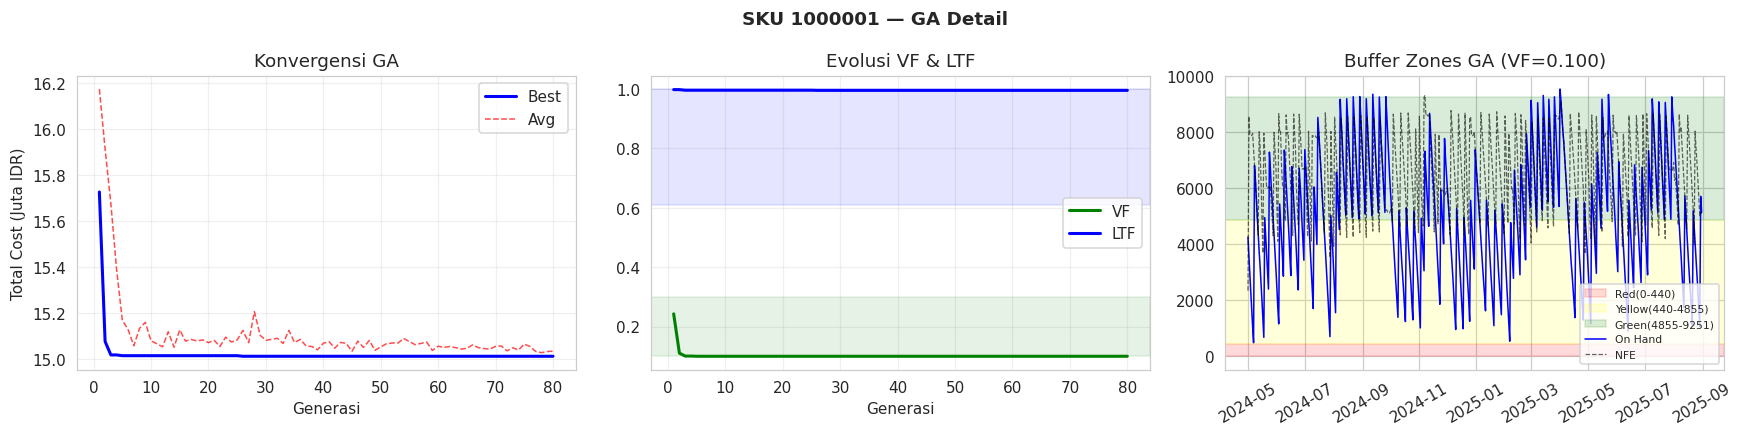

In [93]:
# Visualisasi konvergensi GA
hist = gr['history']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist['generation'], -hist['best_fitness']/1e6, 'b-', lw=2, label='Best')
axes[0].plot(hist['generation'], -hist['avg_fitness']/1e6,  'r--', lw=1, alpha=0.7, label='Avg')
axes[0].set_xlabel('Generasi'); axes[0].set_ylabel('Total Cost (Juta IDR)')
axes[0].set_title('Konvergensi GA'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist['generation'], hist['best_vf'],  'g-', lw=2, label='VF')
axes[1].plot(hist['generation'], hist['best_ltf'], 'b-', lw=2, label='LTF')
axes[1].axhspan(clf['vf_low'],  clf['vf_high'],  alpha=0.1, color='green')
axes[1].axhspan(clf['ltf_low'], clf['ltf_high'], alpha=0.1, color='blue')
axes[1].set_xlabel('Generasi'); axes[1].set_title('Evolusi VF & LTF')
axes[1].legend(); axes[1].grid(alpha=0.3)

df_det = kpi_opt['df_detail'].copy()
df_det['date'] = pd.to_datetime(df_det['date'])
tor,toy,tog = kpi_opt['tor'], kpi_opt['toy'], kpi_opt['tog']
axes[2].axhspan(0,  tor, alpha=0.15, color='red',    label=f'Red(0-{tor:.0f})')
axes[2].axhspan(tor,toy, alpha=0.15, color='yellow',  label=f'Yellow({tor:.0f}-{toy:.0f})')
axes[2].axhspan(toy,tog, alpha=0.15, color='green',   label=f'Green({toy:.0f}-{tog:.0f})')
axes[2].plot(df_det['date'], df_det['OH_end'], 'b-', lw=1, label='On Hand')
axes[2].plot(df_det['date'], df_det['NFE'],    'k--', lw=0.8, alpha=0.6, label='NFE')
axes[2].set_title(f'Buffer Zones GA (VF={gr["vf_opt"]:.3f})')
axes[2].legend(fontsize=7); axes[2].tick_params(axis='x', rotation=30)

plt.suptitle(f'SKU {SKU} — GA Detail', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_ga_sku{SKU}.png', dpi=150, bbox_inches='tight')
plt.show()

## [RUN 4] — Pipeline Lengkap: DDMRP vs ROP

In [94]:
# ── Pilih SKU ──
SKU = 1000001   # ← ganti sesuai kebutuhan

# (Semua langkah di atas sudah jalan — kita lanjutkan dari variabel yang ada)
# Jika ingin SKU berbeda, jalankan ulang dari [RUN 3]

# Simulasi ROP
print("\n📊 Simulasi ROP...")
kpi_rop = simulate_rop(
    demands=clean, dates=dates, dlt=params['dlt'],
    pack_size=moq, unit_price=params['price_ea'],
    hold_cost_per_unit_day=params['hold_cost_per_unit_day'],
    order_cost=params['order_cost'],
    penalty_mult=params['penalty_per_unit'],
    service_factor=1.645, lt_std=params['lt_std'])
print(f"ROP: FR={kpi_rop['fill_rate']*100:.2f}% | "
      f"Cost=Rp{kpi_rop['total_cost']/1e6:.1f}jt | "
      f"Stockout={kpi_rop['n_stockout']}hr | "
      f"SS={kpi_rop['ss']:.0f} | EOQ={kpi_rop['eoq']}")


📊 Simulasi ROP...
ROP: FR=94.63% | Cost=Rp36.0jt | Stockout=42hr | SS=358 | EOQ=4000


In [95]:
# Monte Carlo
print(f"\n🎲 Monte Carlo ({MC_N_SCENARIOS} skenario)...")
mc = run_monte_carlo(clean, fc, dates, gr['vf_opt'], gr['ltf_opt'],
                     params, moq, n_scenarios=MC_N_SCENARIOS)


🎲 Monte Carlo (50 skenario)...
  MC (50 skenario): FR=99.98% | SL≥95%=100.0% | Cost P50=Rp15.2jt


In [96]:
# Tabel perbandingan
print(f"\n{'='*70}")
print(f"  PERBANDINGAN: DDMRP Baseline vs DDMRP GA Hybrid vs ROP")
print(f"{'='*70}")
print(f"  {'Metrik':<22} {'Baseline':>14} {'GA Hybrid':>14} {'ROP':>14}")
print(f"  {'─'*65}")
for label, bv, ov, rv in [
    ('Fill Rate (%)',      f"{kpi_base['fill_rate']*100:.2f}",
                           f"{kpi_opt['fill_rate']*100:.2f}",
                           f"{kpi_rop['fill_rate']*100:.2f}"),
    ('CSL (%)',            f"{kpi_base['csl']*100:.2f}",
                           f"{kpi_opt['csl']*100:.2f}",
                           f"{kpi_rop['csl']*100:.2f}"),
    ('Stockout (hari)',    str(kpi_base['n_stockout']),
                           str(kpi_opt['n_stockout']),
                           str(kpi_rop['n_stockout'])),
    ('Total Cost (jt)',    f"{kpi_base['total_cost']/1e6:.1f}",
                           f"{kpi_opt['total_cost']/1e6:.1f}",
                           f"{kpi_rop['total_cost']/1e6:.1f}"),
    ('Holding Cost (jt)',  f"{kpi_base['hold_cost']/1e6:.1f}",
                           f"{kpi_opt['hold_cost']/1e6:.1f}",
                           f"{kpi_rop['hold_cost']/1e6:.1f}"),
    ('Order Cost (jt)',    f"{kpi_base['order_cost']/1e6:.1f}",
                           f"{kpi_opt['order_cost']/1e6:.1f}",
                           f"{kpi_rop['order_cost']/1e6:.1f}"),
    ('Penalty Cost (jt)', f"{kpi_base['penalty_cost']/1e6:.1f}",
                           f"{kpi_opt['penalty_cost']/1e6:.1f}",
                           f"{kpi_rop['penalty_cost']/1e6:.1f}"),
    ('Avg OH (unit)',      f"{kpi_base['avg_oh']:.0f}",
                           f"{kpi_opt['avg_oh']:.0f}",
                           f"{kpi_rop['avg_oh']:.0f}"),
    ('N Orders',           str(kpi_base['n_orders']),
                           str(kpi_opt['n_orders']),
                           str(kpi_rop['n_orders'])),
    ('VF',                 f"{clf['vf_init']:.4f}",
                           f"{gr['vf_opt']:.4f}", '-'),
    ('LTF',               f"{clf['ltf_init']:.4f}",
                           f"{gr['ltf_opt']:.4f}", '-'),
    ('MC SL≥95%',         '-',
                           f"{mc['sl_met_pct']:.1f}%", '-'),
]:
    print(f"  {label:<22} {bv:>14} {ov:>14} {rv:>14}")


  PERBANDINGAN: DDMRP Baseline vs DDMRP GA Hybrid vs ROP
  Metrik                       Baseline      GA Hybrid            ROP
  ─────────────────────────────────────────────────────────────────
  Fill Rate (%)                  100.00         100.00          94.63
  CSL (%)                        100.00         100.00          91.39
  Stockout (hari)                     0              0             42
  Total Cost (jt)                  16.2           15.0           36.0
  Holding Cost (jt)                 5.7            5.6            2.3
  Order Cost (jt)                  10.5            9.4           10.8
  Penalty Cost (jt)                 0.0            0.0           22.9
  Avg OH (unit)                    5155           4994           2022
  N Orders                           70             63             72
  VF                             0.2000         0.1000              -
  LTF                            0.8050         0.9955              -
  MC SL≥95%                       

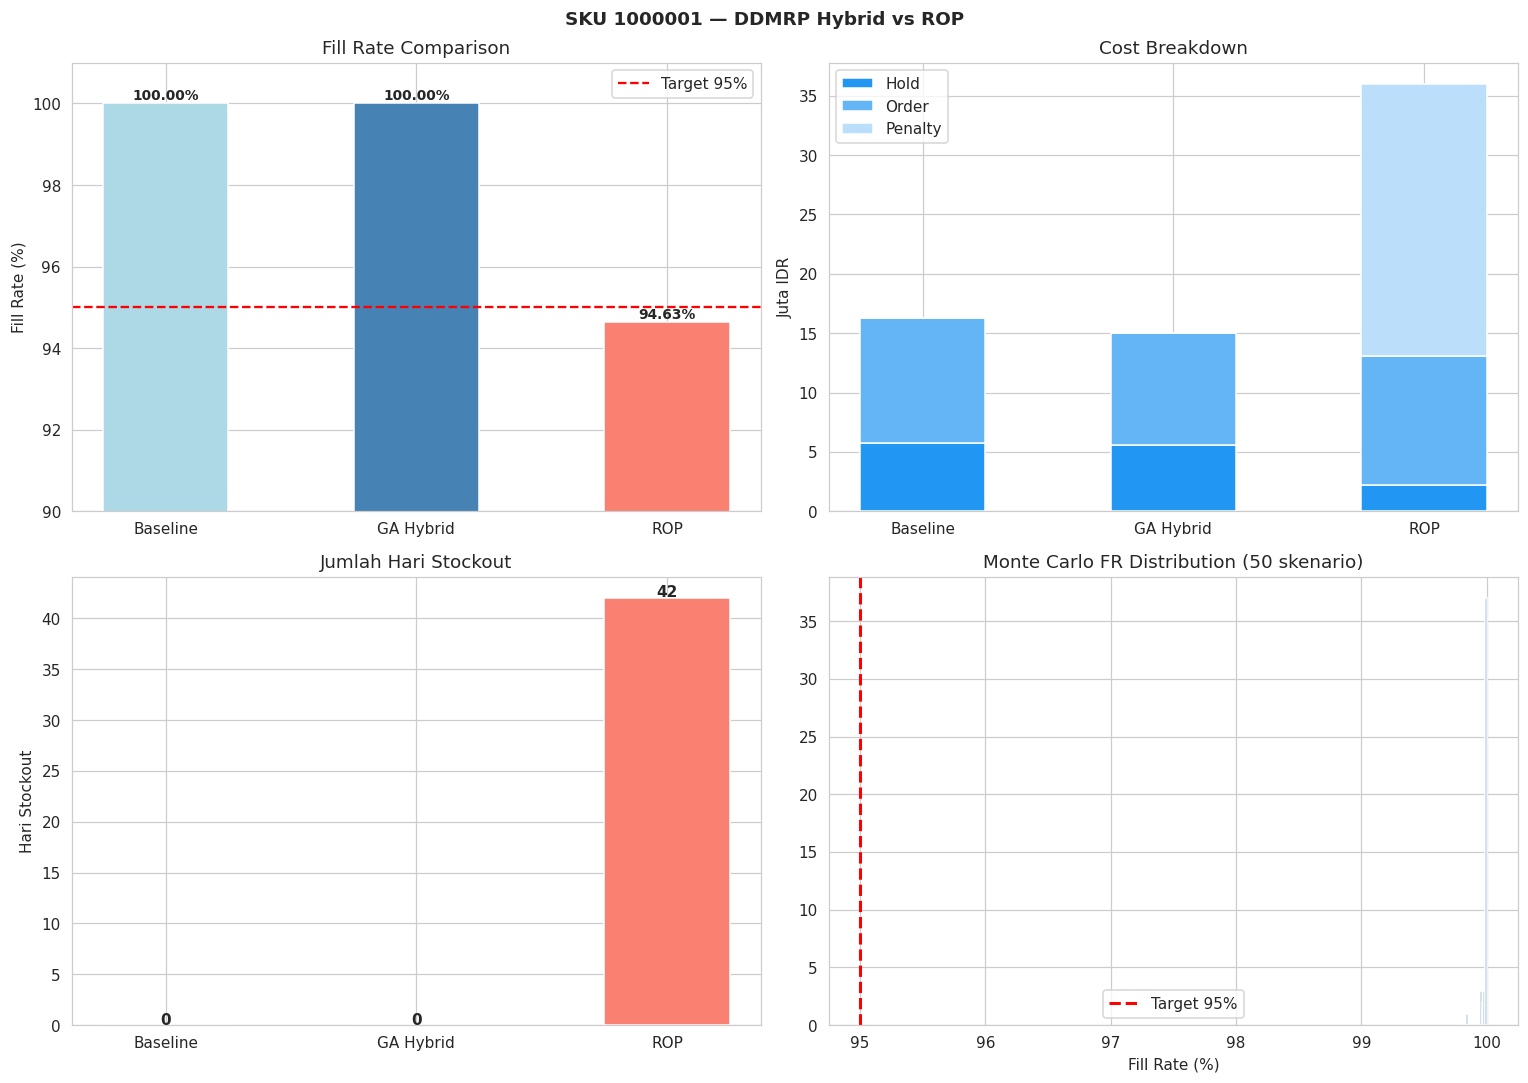

In [97]:
# Visualisasi perbandingan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fill Rate bar
methods = ['Baseline','GA Hybrid','ROP']
fr_vals = [kpi_base['fill_rate']*100, kpi_opt['fill_rate']*100, kpi_rop['fill_rate']*100]
colors  = ['lightblue','steelblue','salmon']
axes[0,0].bar(methods, fr_vals, color=colors, edgecolor='white', width=0.5)
axes[0,0].axhline(95, color='red', ls='--', lw=1.5, label='Target 95%')
axes[0,0].set_ylim(90,101); axes[0,0].set_ylabel('Fill Rate (%)')
axes[0,0].set_title('Fill Rate Comparison'); axes[0,0].legend()
for i,(m,v) in enumerate(zip(methods,fr_vals)):
    axes[0,0].text(i, v+0.1, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

# 2. Cost breakdown
cost_data = {
    'Baseline': [kpi_base['hold_cost'],kpi_base['order_cost'],kpi_base['penalty_cost']],
    'GA Hybrid':[kpi_opt['hold_cost'], kpi_opt['order_cost'], kpi_opt['penalty_cost']],
    'ROP':      [kpi_rop['hold_cost'], kpi_rop['order_cost'], kpi_rop['penalty_cost']],
}
x=np.arange(3); w=0.5; lbls=['Hold','Order','Penalty']; clrs=['#2196F3','#64B5F6','#BBDEFB']
bot=np.zeros(3)
for i,(lbl,clr) in enumerate(zip(lbls,clrs)):
    vals=[cd[i]/1e6 for cd in cost_data.values()]
    axes[0,1].bar(x, vals, w, bottom=bot, label=lbl, color=clr, edgecolor='white')
    bot+=np.array(vals)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(methods)
axes[0,1].set_ylabel('Juta IDR'); axes[0,1].set_title('Cost Breakdown'); axes[0,1].legend()

# 3. Stockout
so_vals=[kpi_base['n_stockout'],kpi_opt['n_stockout'],kpi_rop['n_stockout']]
axes[1,0].bar(methods, so_vals, color=colors, edgecolor='white', width=0.5)
axes[1,0].set_ylabel('Hari Stockout'); axes[1,0].set_title('Jumlah Hari Stockout')
for i,v in enumerate(so_vals):
    axes[1,0].text(i, v+0.1, str(v), ha='center', fontsize=10, fontweight='bold')

# 4. Monte Carlo FR distribution
axes[1,1].hist(mc['df_mc']['fill_rate']*100, bins=15, color='steelblue', edgecolor='white')
axes[1,1].axvline(95, color='red', ls='--', lw=2, label='Target 95%')
axes[1,1].set_xlabel('Fill Rate (%)'); axes[1,1].set_title(f'Monte Carlo FR Distribution ({MC_N_SCENARIOS} skenario)')
axes[1,1].legend()

plt.suptitle(f'SKU {SKU} — DDMRP Hybrid vs ROP', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_comparison_sku{SKU}.png', dpi=150, bbox_inches='tight')
plt.show()

## [RUN 5] — Sensitivity Analysis

Variasi parameter cost untuk melihat dampaknya terhadap KPI.


In [98]:
# ── Pilih SKU ──
SKU = 1000001   # ← ganti sesuai kebutuhan
# (gunakan variabel clean, fc, dates, clf, gr, moq dari RUN 3)

sens_rows = []
print("Menjalankan sensitivity analysis...")

for oc_label, oc_mult in [('300rb',0.2),('750rb',0.5),('1.5jt',1.0),('3jt',2.0)]:
    for pf_label, pf in [('10%',0.10),('20%',0.20),('30%',0.30),('50%',0.50)]:
        oc  = params['order_cost'] * oc_mult
        pen = params['price_ea']  * pf
        # MOQ menyesuaikan order cost baru
        moq_s = params['moq']
        kpi_s = simulate_ddmrp(clean, fc, dates,
                                gr['vf_opt'], gr['ltf_opt'],
                                params['dlt'], moq_s, params['price_ea'],
                                params['hold_cost_per_unit_day'], oc, pen,
                                lt_std=0.0)
        # ROP pembanding
        kpi_r = simulate_rop(clean, dates, params['dlt'], moq_s,
                              params['price_ea'], params['hold_cost_per_unit_day'],
                              oc, pen, service_factor=1.645, lt_std=0.0)
        sens_rows.append({
            'OrderCost': oc_label, 'PenaltyFactor': pf_label,
            'DDMRP_Cost_jt': round(kpi_s['total_cost']/1e6,1),
            'ROP_Cost_jt':   round(kpi_r['total_cost']/1e6,1),
            'DDMRP_FR%': round(kpi_s['fill_rate']*100,2),
            'ROP_FR%':   round(kpi_r['fill_rate']*100,2),
            'DDMRP_Stockout': kpi_s['n_stockout'],
            'ROP_Stockout':   kpi_r['n_stockout'],
            'MOQ_used': moq_s,
        })

df_sens = pd.DataFrame(sens_rows)
display(df_sens)

Menjalankan sensitivity analysis...


,OrderCost,PenaltyFactor,DDMRP_Cost_jt,ROP_Cost_jt,DDMRP_FR%,ROP_FR%,DDMRP_Stockout,ROP_Stockout,MOQ_used
0,300rb,10%,7.5,8.0,100.0,97.49,0,32,4000
1,300rb,20%,7.5,11.5,100.0,97.49,0,32,4000
2,300rb,30%,7.5,15.1,100.0,97.49,0,32,4000
3,300rb,50%,7.5,22.2,100.0,97.49,0,32,4000
4,750rb,10%,10.3,11.3,100.0,97.49,0,32,4000
5,750rb,20%,10.3,14.9,100.0,97.49,0,32,4000
6,750rb,30%,10.3,18.4,100.0,97.49,0,32,4000
7,750rb,50%,10.3,25.6,100.0,97.49,0,32,4000
8,1.5jt,10%,15.0,16.8,100.0,97.49,0,32,4000
9,1.5jt,20%,15.0,20.4,100.0,97.49,0,32,4000


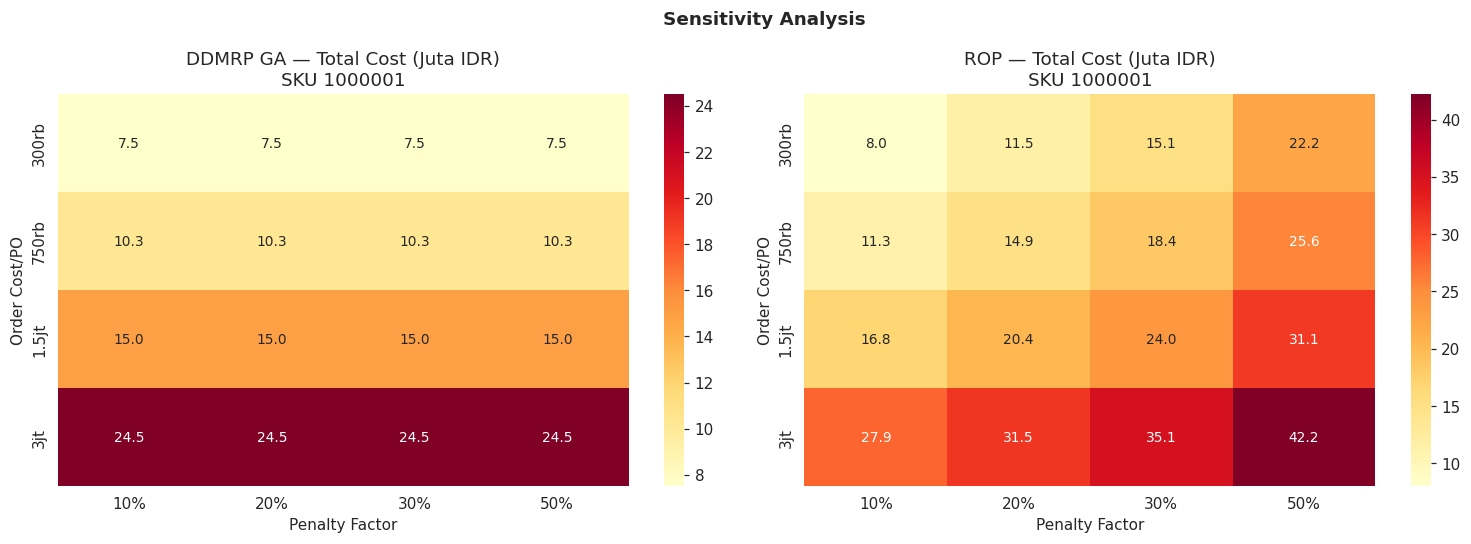

In [99]:
# Heatmap sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p_ddmrp = df_sens.pivot_table(values='DDMRP_Cost_jt',
    index='OrderCost', columns='PenaltyFactor', aggfunc='mean')
p_rop   = df_sens.pivot_table(values='ROP_Cost_jt',
    index='OrderCost', columns='PenaltyFactor', aggfunc='mean')
order_idx = ['300rb','750rb','1.5jt','3jt']

sns.heatmap(p_ddmrp.reindex(order_idx), annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], annot_kws={'size':9})
axes[0].set_title(f'DDMRP GA — Total Cost (Juta IDR)\nSKU {SKU}')
axes[0].set_xlabel('Penalty Factor'); axes[0].set_ylabel('Order Cost/PO')

sns.heatmap(p_rop.reindex(order_idx), annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], annot_kws={'size':9})
axes[1].set_title(f'ROP — Total Cost (Juta IDR)\nSKU {SKU}')
axes[1].set_xlabel('Penalty Factor'); axes[1].set_ylabel('Order Cost/PO')

plt.suptitle('Sensitivity Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_sensitivity_sku{SKU}.png', dpi=150, bbox_inches='tight')
plt.show()

## [RUN 6] — Export Excel

In [100]:
# Export hasil satu SKU ke Excel
out = f'{OUTPUT_DIR}/DDMRP_SKU{SKU}_Results.xlsx'

with pd.ExcelWriter(out, engine='openpyxl') as w:

    # Sheet 1: Perbandingan ringkasan
    pd.DataFrame([
        {'Metrik':'Fill Rate (%)','Baseline':kpi_base['fill_rate']*100,
         'GA Hybrid':kpi_opt['fill_rate']*100,'ROP':kpi_rop['fill_rate']*100},
        {'Metrik':'CSL (%)','Baseline':kpi_base['csl']*100,
         'GA Hybrid':kpi_opt['csl']*100,'ROP':kpi_rop['csl']*100},
        {'Metrik':'Stockout (hari)','Baseline':kpi_base['n_stockout'],
         'GA Hybrid':kpi_opt['n_stockout'],'ROP':kpi_rop['n_stockout']},
        {'Metrik':'Total Cost','Baseline':kpi_base['total_cost'],
         'GA Hybrid':kpi_opt['total_cost'],'ROP':kpi_rop['total_cost']},
        {'Metrik':'Holding Cost','Baseline':kpi_base['hold_cost'],
         'GA Hybrid':kpi_opt['hold_cost'],'ROP':kpi_rop['hold_cost']},
        {'Metrik':'Order Cost','Baseline':kpi_base['order_cost'],
         'GA Hybrid':kpi_opt['order_cost'],'ROP':kpi_rop['order_cost']},
        {'Metrik':'Penalty Cost','Baseline':kpi_base['penalty_cost'],
         'GA Hybrid':kpi_opt['penalty_cost'],'ROP':kpi_rop['penalty_cost']},
        {'Metrik':'Avg OH (unit)','Baseline':kpi_base['avg_oh'],
         'GA Hybrid':kpi_opt['avg_oh'],'ROP':kpi_rop['avg_oh']},
        {'Metrik':'N Orders','Baseline':kpi_base['n_orders'],
         'GA Hybrid':kpi_opt['n_orders'],'ROP':kpi_rop['n_orders']},
        {'Metrik':'VF','Baseline':clf['vf_init'],'GA Hybrid':gr['vf_opt'],'ROP':'-'},
        {'Metrik':'LTF','Baseline':clf['ltf_init'],'GA Hybrid':gr['ltf_opt'],'ROP':'-'},
        {'Metrik':'MC SL≥95%','Baseline':'-','GA Hybrid':mc['sl_met_pct'],'ROP':'-'},
    ]).to_excel(w, sheet_name='1_Comparison', index=False)

    # Sheet 2-4: Detail harian
    kpi_opt['df_detail'].to_excel(w, sheet_name='2_DDMRP_GA_Daily', index=False)
    kpi_base['df_detail'].to_excel(w, sheet_name='3_DDMRP_Base_Daily', index=False)
    kpi_rop['df_detail'].to_excel(w, sheet_name='4_ROP_Daily', index=False)

    # Sheet 5: GA History
    gr['history'].to_excel(w, sheet_name='5_GA_History', index=False)

    # Sheet 6: Monte Carlo
    mc['df_mc'].to_excel(w, sheet_name='6_Monte_Carlo', index=False)

    # Sheet 7: Sensitivity
    df_sens.to_excel(w, sheet_name='7_Sensitivity', index=False)

    # Sheet 8: Klasifikasi
    pd.DataFrame([clf]).to_excel(w, sheet_name='8_Classification', index=False)

    # Sheet 9: Forecast ranking
    result_fc['comparison'].to_excel(w, sheet_name='9_Forecast_Models', index=False)

print(f"✅ Saved: {out}")
print("\nSheet yang dihasilkan:")
print("  1_Comparison    — Ringkasan perbandingan 3 metode")
print("  2_DDMRP_GA_Daily — Detail harian DDMRP GA optimal")
print("  3_DDMRP_Base_Daily — Detail harian DDMRP baseline")
print("  4_ROP_Daily     — Detail harian ROP")
print("  5_GA_History    — Konvergensi GA per generasi")
print("  6_Monte_Carlo   — Hasil 50 skenario MC")
print("  7_Sensitivity   — Analisis sensitivitas")
print("  8_Classification — Hasil ADI-CV² + buffer params")
print("  9_Forecast_Models — Ranking semua model forecast")

✅ Saved: /content/DDMRP_SKU1000001_Results.xlsx

Sheet yang dihasilkan:
  1_Comparison    — Ringkasan perbandingan 3 metode
  2_DDMRP_GA_Daily — Detail harian DDMRP GA optimal
  3_DDMRP_Base_Daily — Detail harian DDMRP baseline
  4_ROP_Daily     — Detail harian ROP
  5_GA_History    — Konvergensi GA per generasi
  6_Monte_Carlo   — Hasil 50 skenario MC
  7_Sensitivity   — Analisis sensitivitas
  8_Classification — Hasil ADI-CV² + buffer params
  9_Forecast_Models — Ranking semua model forecast


**---ANALISIS---**

In [101]:
# MAE rata-rata semua 20 SKU
mae_list = []
err_list = []

for sku in all_skus:
    df_tmp = get_sku_demand(data, int(sku))
    result_tmp = run_forecast(df_tmp, sku, verbose=False)
    mae  = result_tmp['best_metrics']['MAE']
    adu  = result_tmp['adu']   # sudah dari data clean (setelah perbaikan tadi)
    err  = mae / adu * 100
    mae_list.append(mae)
    err_list.append(err)
    print(f"SKU {sku} | Model: {result_tmp['best_model']:<25} | "
          f"MAE: {mae:>6.1f} | Error%: {err:.1f}%")

print(f"\nRata-rata MAE    : {np.mean(mae_list):.2f} unit/hari")
print(f"Rata-rata Error% : {np.mean(err_list):.1f}%")

✅ SKU 1000001 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 301,099
SKU 1000001 | Model: M26-Ensemble-GA           | MAE:   44.7 | Error%: 7.1%
✅ SKU 1000002 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 221,665
SKU 1000002 | Model: M25-DOW-EN                | MAE:   36.6 | Error%: 7.7%
✅ SKU 1000003 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 371,597
SKU 1000003 | Model: M26-Ensemble-GA           | MAE:   56.0 | Error%: 7.4%
✅ SKU 1000004 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 71,100
SKU 1000004 | Model: M10-MLP+Promo             | MAE:   16.6 | Error%: 8.1%
✅ SKU 1000005 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 130,360
SKU 1000005 | Model: M11-EN+Promo              | MAE:   29.9 | Error%: 9.9%
✅ SKU 1000006 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 47,427
SKU 1000006 | Model: M10-MLP+Promo             | MAE:   13.7 | Error%: 11.8%
✅ SKU 1000007 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 99,965
SKU 100

In [104]:
# Ringkasan anomali semua SKU
print("=== RINGKASAN ANOMALI DEMAND ===\n")
summary_rows = []

for sku in all_skus:
    df_tmp = get_sku_demand(data, int(sku))
    s      = df_tmp['Demand'].values.astype(float)
    adu    = float(np.mean(s[s>0]))
    _, rpt = clean_demand_adaptive(s, df_tmp['Date'].reset_index(drop=True),
                                    adu=adu, verbose=False)
    n_low  = int((rpt['Tipe']=='LOW').sum())  if len(rpt)>0 else 0
    n_high = int((rpt['Tipe']=='HIGH').sum()) if len(rpt)>0 else 0
    summary_rows.append({
        'SKU'       : sku,
        'Grup'      : get_sku_params(data, int(sku))['group'],
        'ADU'       : round(adu, 1),
        'N_Anomali' : len(rpt),
        'N_LOW'     : n_low,
        'N_HIGH'    : n_high,
        'Pct_%'     : round(len(rpt)/len(s)*100, 1),
    })

df_anom = pd.DataFrame(summary_rows).sort_values('N_Anomali', ascending=False)
print(df_anom.to_string(index=False))

total      = df_anom['N_Anomali'].sum()
total_baris= 9760
pct_total  = round(total/total_baris*100, 1)
sku_max    = df_anom.iloc[0]
sku_min    = df_anom.iloc[-1]

print(f"\n{'='*55}")
print(f"Total anomali    : {total} dari {total_baris} baris ({pct_total}%)")
print(f"SKU terbanyak    : {sku_max['SKU']} ({sku_max['Grup']}) — {sku_max['N_Anomali']} hari")
print(f"SKU paling bersih: {sku_min['SKU']} ({sku_min['Grup']}) — {sku_min['N_Anomali']} hari")

=== RINGKASAN ANOMALI DEMAND ===

✅ SKU 1000001 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 301,099
✅ SKU 1000002 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 221,665
✅ SKU 1000003 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 371,597
✅ SKU 1000004 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 71,100
✅ SKU 1000005 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 130,360
✅ SKU 1000006 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 47,427
✅ SKU 1000007 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 99,965
✅ SKU 1000008 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 110,745
✅ SKU 1000009 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 269,902
✅ SKU 1000010 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 167,482
✅ SKU 1000011 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 102,072
✅ SKU 1000012 | 2024-05-01 s/d 2025-08-31 | 488 hari | demand total: 79,788
✅ SKU 1000013 | 2024-05-01 s/d 2025-08-31 | 48